# Modelado — Colono IA

Regresión lineal que predice los puntos de una pareja de vértices, y agrupamiento que descubre
las familias de estrategia.

Continúa de `01_eda.ipynb`, que mostró que los pips no bastan, que la combinación de recursos
importa y que las 12 variables del modelo no son redundantes (ningún VIF supera 5.5).

**Relación con el documento final.** El notebook sigue el mismo orden que el **Capítulo 5
(Modelación)** del documento, y cada gráfica es la misma que aparece ahí. Al pie de cada gráfica
se indica a qué figura del documento corresponde.

## 1. Preparación

In [1]:
# En Google Colab, descomenta para clonar el repositorio:
# !git clone https://github.com/AnaaBohorquez/catanai.git
# %cd catanai

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# La raíz del proyecto: la primera carpeta, subiendo desde la actual, que tiene
# data/processed. Así funciona igual desde notebooks/, desde la raíz y en Colab.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
RUTA = RAIZ / "data" / "processed" / "parejas.csv"
OBJETIVO = "puntos"

datos = pd.read_csv(RUTA)
print(f"{len(datos):,} parejas de {datos['tablero_id'].nunique()} tableros")

38,355 parejas de 200 tableros


In [2]:
# Estilo de las gráficas: el mismo del documento y de 01_eda.ipynb.
AZUL, TERRACOTA, VERDE, DORADO = "#2F6AA3", "#C8643C", "#1F978A", "#A8861F"
TINTA, TENUE, REJILLA, GRIS = "#2b2b2b", "#6b6b6b", "#e6e6e6", "#9e9e9e"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.edgecolor": "#bdbdbd", "axes.labelcolor": TINTA,
    "xtick.color": TENUE, "ytick.color": TENUE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 9.5, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "figure.dpi": 110,
})

## 2. Qué variables entran al modelo

El EDA mostró que muchas variables miden lo mismo. Aquí se usa un conjunto **compacto de 12**,
elegido por dos criterios: que aporte información y que **se pueda explicar en voz alta**, porque
los coeficientes son la explicación que la app le da al usuario.

Más abajo se compara contra el modelo con todas las variables para comprobar qué tanto se pierde.

In [3]:
VARIABLES = [
    "produccion_efectiva",    # producción ajustada por lo que se puede gastar
    "par_camino",             # madera con ladrillo
    "par_ciudad",             # trigo con mineral, ponderada por su costo
    "trio_desarrollo",        # trigo, oveja y mineral
    "cuarteto_poblado",       # los cuatro recursos de un poblado
    "desequilibrio",          # concentración de la producción
    "puerto_alineado",        # puerto 2:1 del recurso que más produces
    "puerto_generico",        # puerto 3:1
    "vertices_expansion_2",   # espacio para crecer
    "jugadores",              # 3 o 4
    "num_hexagonos",          # distingue costa de centro
    "solapamiento",           # si los dos poblados comparten hexágono
]

TODAS = [c for c in datos.columns if c not in ["tablero_id", "pareja_id", OBJETIVO]]
print(f"Compacto: {len(VARIABLES)} variables | Completo: {len(TODAS)}")

Compacto: 12 variables | Completo: 40


## 3. Preparación de los datos

### 3.1 Partición por tablero

Un tablero entero va a entrenamiento o a prueba, nunca partido. Es como se usa el modelo de
verdad: la app recibe tableros que nunca ha visto. (En `01_eda.ipynb`, Sección 6, se comparó con
la partición ingenua por filas: la diferencia es pequeña, pero se conserva la partición por
tablero porque es la que corresponde al problema.)

In [4]:
particion = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
i_entrena, i_prueba = next(particion.split(datos, datos[OBJETIVO], groups=datos["tablero_id"]))
entrena, prueba = datos.iloc[i_entrena], datos.iloc[i_prueba]

print(f"Entrenamiento: {len(entrena):,} parejas de {entrena['tablero_id'].nunique()} tableros")
print(f"Prueba:        {len(prueba):,} parejas de {prueba['tablero_id'].nunique()} tableros")
print(f"Tableros compartidos: {len(set(entrena['tablero_id']) & set(prueba['tablero_id']))}")

Entrenamiento: 28,769 parejas de 150 tableros
Prueba:        9,586 parejas de 50 tableros
Tableros compartidos: 0


### 3.2 Estandarización

Se estandarizan las variables antes de ajustar la regresión. Así los coeficientes quedan en la
misma escala y se pueden comparar entre sí: cada uno dice cuántos puntos cambia la predicción al
mover esa variable una desviación estándar. El `StandardScaler` va dentro del *pipeline*, así que
la media y la desviación se calculan solo con los datos de entrenamiento.

No hace falta ningún otro tratamiento: no hay faltantes que imputar, los valores extremos se
conservan (`01_eda.ipynb`, Sección 3.2) y todas las variables ya son numéricas.

## 4. Modelación supervisada

### 4.1 Modelos evaluados

La regresión lineal con 12 variables se compara con dos referencias y dos alternativas más
complejas:

- **Media**: estima para toda pareja el promedio de entrenamiento. Es el piso.
- **Solo pips**: regresión con los pips totales como única variable; la regla del jugador.
- **Lineal con 40 variables**: la misma regresión con todas las variables.
- **Gradient boosting** (12 y 40 variables): un ensamble de árboles que se ajustan uno tras otro,
  cada uno corrigiendo los errores del anterior. Capta relaciones no lineales e interacciones.

In [5]:
def lineal():
    return make_pipeline(StandardScaler(), LinearRegression())

def boosting():
    return HistGradientBoostingRegressor(random_state=0)

candidatos = {
    "Solo pips":           (["pips_totales"], lineal),
    "Lineal 12 variables": (VARIABLES, lineal),
    "Lineal 40 variables": (TODAS, lineal),
    "Boosting 12 variables": (VARIABLES, boosting),
    "Boosting 40 variables": (TODAS, boosting),
}

predicciones = {"Media (referencia)": np.full(len(prueba), entrena[OBJETIVO].mean())}
for nombre, (columnas, crear) in candidatos.items():
    m = crear().fit(entrena[columnas], entrena[OBJETIVO])
    predicciones[nombre] = m.predict(prueba[columnas])

tabla = pd.DataFrame({
    nombre: {
        "R²": r2_score(prueba[OBJETIVO], p),
        "MAE": mean_absolute_error(prueba[OBJETIVO], p),
        "RMSE": mean_squared_error(prueba[OBJETIVO], p) ** 0.5,
    }
    for nombre, p in predicciones.items()
}).T.round(3)
tabla

,R²,MAE,RMSE
Media (referencia),-0.000,1.223,1.596
Solo pips,0.173,1.093,1.451
Lineal 12 variables,0.642,0.695,0.955
Lineal 40 variables,0.676,0.646,0.908
Boosting 12 variables,0.772,0.516,0.762
Boosting 40 variables,0.877,0.377,0.560


La regresión con 12 variables explica alrededor del 64 % de la variación de los puntos, frente al
17 % de los pips solos, y baja el error medio de 1.09 a 0.70 puntos. Añadir las otras 28 variables
apenas sube el R² unas centésimas. El *gradient boosting* es claramente más preciso. La pregunta
es si esa precisión extra se traduce en **elegir mejor**, que es lo que la app necesita
(Sección 4.3).

Se guarda el modelo elegido para el resto del notebook:

In [6]:
modelo = lineal().fit(entrena[VARIABLES], entrena[OBJETIVO])
prediccion = modelo.predict(prueba[VARIABLES])
r2 = r2_score(prueba[OBJETIVO], prediccion)
mae = mean_absolute_error(prueba[OBJETIVO], prediccion)
print(f"R²  = {r2:.3f}")
print(f"MAE = {mae:.3f} puntos")
print(f"Desviación del objetivo = {prueba[OBJETIVO].std():.3f} puntos")

R²  = 0.642
MAE = 0.695 puntos
Desviación del objetivo = 1.596 puntos


### 4.2 Validación cruzada agrupada

Para comprobar que el resultado no depende de una partición afortunada, se repite la evaluación
en cinco bloques de 40 tableros cada uno (`GroupKFold`).

In [7]:
for nombre in ["Lineal 12 variables", "Boosting 12 variables"]:
    columnas, crear = candidatos[nombre]
    puntajes = []
    for i_tr, i_te in GroupKFold(n_splits=5).split(datos, datos[OBJETIVO], groups=datos["tablero_id"]):
        m = crear().fit(datos.iloc[i_tr][columnas], datos.iloc[i_tr][OBJETIVO])
        puntajes.append(r2_score(datos.iloc[i_te][OBJETIVO], m.predict(datos.iloc[i_te][columnas])))
    print(f"{nombre:22s} R² = {np.mean(puntajes):.3f} ± {np.std(puntajes):.3f}   {np.round(puntajes, 3)}")

Lineal 12 variables    R² = 0.620 ± 0.016   [0.613 0.633 0.629 0.634 0.592]
Boosting 12 variables  R² = 0.754 ± 0.016   [0.749 0.771 0.756 0.77  0.726]


La poca variación entre bloques indica que ambos modelos son estables y generalizan a tableros nuevos.

### 4.3 La métrica que de verdad importa

El R² mide qué tan bien predice el modelo. Pero la app no predice: **elige**. Lo que importa es si
la pareja que recomienda es mejor que la que elegiría el usuario por su cuenta.

Se compara, en cada tablero de prueba, los puntos simulados de:

- **la pareja que cada modelo pone en primer lugar**;
- **la mejor pareja real del tablero**, el máximo alcanzable;
- **el promedio de todas las parejas**, que equivale a elegir al azar.

La fila «Solo pips» es la pareja con más pips, que es lo que hace cualquier jugador.

In [8]:
evaluacion = prueba[["tablero_id", OBJETIVO]].copy()
techo = evaluacion.groupby("tablero_id")[OBJETIVO].max().mean()
azar = evaluacion.groupby("tablero_id")[OBJETIVO].mean().mean()

def puntos_de_la_elegida(p):
    """Promedio, sobre los tableros de prueba, de los puntos de la pareja con mayor predicción."""
    e = evaluacion.assign(p=p)
    return np.mean([t.loc[t["p"].idxmax(), OBJETIVO] for _, t in e.groupby("tablero_id")])

eleccion = pd.DataFrame({
    nombre: {"puntos de la elegida": puntos_de_la_elegida(p)}
    for nombre, p in predicciones.items() if nombre != "Media (referencia)"
}).T
eleccion["% del margen capturado"] = (eleccion["puntos de la elegida"] - azar) / (techo - azar) * 100

print(f"Mejor pareja posible (promedio): {techo:.2f}")
print(f"Elegir al azar (promedio):       {azar:.2f}\n")
eleccion.round(2)

Mejor pareja posible (promedio): 9.01
Elegir al azar (promedio):       4.67



,puntos de la elegida,% del margen capturado
Solo pips,5.94,29.15
Lineal 12 variables,8.03,77.49
Lineal 40 variables,8.02,77.06
Boosting 12 variables,8.32,84.18
Boosting 40 variables,8.21,81.62


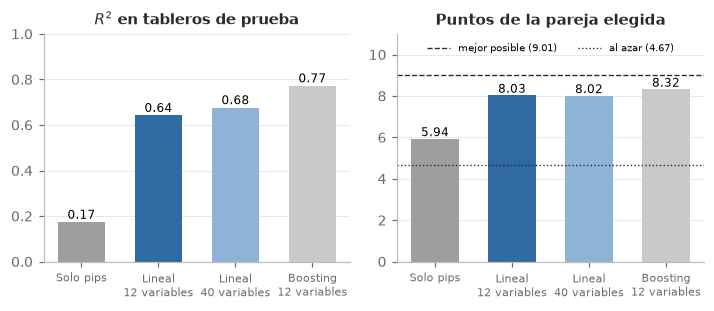

In [9]:
nombres = ["Solo pips", "Lineal 12 variables", "Lineal 40 variables", "Boosting 12 variables"]
etiquetas = ["Solo pips", "Lineal\n12 variables", "Lineal\n40 variables", "Boosting\n12 variables"]
colores = [GRIS, AZUL, "#8fb3d6", "#c9c9c9"]
valores_r2 = [tabla.loc[n, "R²"] for n in nombres]
valores_eleccion = [eleccion.loc[n, "puntos de la elegida"] for n in nombres]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.9))
a1.bar(range(4), valores_r2, color=colores, width=0.62)
for x, v in enumerate(valores_r2):
    a1.text(x, v + 0.015, f"{v:.2f}", ha="center", fontsize=8)
a1.set_xticks(range(4))
a1.set_xticklabels(etiquetas, fontsize=7.2)
a1.set_ylim(0, 1)
a1.set_title("$R^2$ en tableros de prueba")
a1.grid(axis="x", visible=False)

a2.bar(range(4), valores_eleccion, color=colores, width=0.62)
for x, v in enumerate(valores_eleccion):
    a2.text(x, v + 0.12, f"{np.round(v, 2):.2f}", ha="center", fontsize=8)
a2.axhline(techo, color=TINTA, lw=0.9, ls="--", label=f"mejor posible ({techo:.2f})")
a2.axhline(azar, color=TINTA, lw=0.9, ls=":", label=f"al azar ({azar:.2f})")
a2.legend(fontsize=6.8, frameon=False, ncol=2, loc="upper center", handlelength=2.2)
a2.set_xticks(range(4))
a2.set_xticklabels(etiquetas, fontsize=7.2)
a2.set_ylim(0, 11)
a2.set_title("Puntos de la pareja elegida")
a2.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 5: figura «$R^2$ de cada modelo y puntos promedio de la pareja que elige».*

In [10]:
# ¿Qué tan bien ordena el modelo las parejas DENTRO de cada tablero?
# Correlación de rangos de Spearman entre el orden estimado y el orden real.
e = prueba.assign(p=prediccion)
spearman_modelo = np.mean([t["p"].corr(t[OBJETIVO], method="spearman") for _, t in e.groupby("tablero_id")])
spearman_pips = np.mean([t["pips_totales"].corr(t[OBJETIVO], method="spearman") for _, t in e.groupby("tablero_id")])
print(f"Spearman dentro de cada tablero — modelo: {spearman_modelo:.2f} | pips: {spearman_pips:.2f}")

ventaja = eleccion.loc["Lineal 12 variables", "puntos de la elegida"] - eleccion.loc["Solo pips", "puntos de la elegida"]
print(f"Ventaja del modelo sobre los pips: {ventaja:+.2f} puntos por partida")

Spearman dentro de cada tablero — modelo: 0.77 | pips: 0.42
Ventaja del modelo sobre los pips: +2.10 puntos por partida


**Este es el número del proyecto.** Elegir con el modelo vale alrededor de **dos puntos de
victoria más** que elegir por pips, que es el criterio que usa todo jugador en la mesa. En una
partida que se gana con 10 puntos, es mucho.

### 4.4 Selección del modelo

Con la métrica de elección, la ventaja del *gradient boosting* se reduce mucho: su pareja elegida
saca unas tres décimas más que la de la regresión lineal, y con 40 variables no mejora. La
regresión con 40 variables elige igual que la de 12.

Se elige la **regresión lineal con 12 variables** por tres razones:

1. **Es interpretable, y la interpretación es parte del producto.** Los coeficientes son la
   explicación que dan la app y el asistente. Un ensamble de cientos de árboles no la ofrece.
2. **La ganancia del modelo complejo es pequeña donde importa.** Frente a los pips, la lineal ya
   gana unos dos puntos; el *boosting* añadiría tres décimas a cambio de perder la explicación.
3. **Las 12 variables bastan.** Usar las 40 no mejora la elección y vuelve inestables los
   coeficientes.

**¿Qué es el 36 % que el modelo no explica?** No es, en su mayoría, azar de los dados. Al repetir
12 veces la simulación de una misma pareja (cada vez con 40 partidas y dados distintos), su
promedio cambia con una desviación estándar de unos 0.28 puntos. Ese ruido es una parte muy
pequeña de la varianza:

In [11]:
ruido = 0.28   # desviación medida repitiendo 12 veces la simulación de una misma pareja
print(f"Varianza del objetivo:      {datos[OBJETIVO].var():.2f}")
print(f"Varianza del ruido (0.28²): {ruido ** 2:.3f}")
print(f"El ruido explica {ruido ** 2 / datos[OBJETIVO].var():.1%} de la varianza")

Varianza del objetivo:      2.47
Varianza del ruido (0.28²): 0.078
El ruido explica 3.2% de la varianza


Así que la mayor parte de lo no explicado son **relaciones no lineales** entre las variables, que
la regresión no capta y el *boosting* sí. Es una mejora posible para una versión futura.

### 4.5 Qué dicen los coeficientes

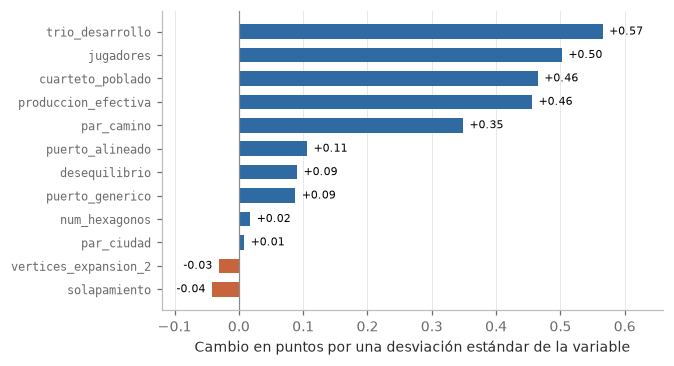

,coeficiente
trio_desarrollo,0.566
jugadores,0.502
cuarteto_poblado,0.465
produccion_efectiva,0.456
par_camino,0.349
puerto_alineado,0.106
desequilibrio,0.091
puerto_generico,0.088
solapamiento,-0.042
vertices_expansion_2,-0.031


In [12]:
coeficientes = pd.Series(modelo[-1].coef_, index=VARIABLES).sort_values()

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.barh(range(len(coeficientes)), coeficientes.values,
        color=[TERRACOTA if v < 0 else AZUL for v in coeficientes.values], height=0.62)
ax.set_yticks(range(len(coeficientes)))
ax.set_yticklabels(coeficientes.index, fontsize=8, family="DejaVu Sans Mono")
for k, v in enumerate(coeficientes.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), k, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5)
ax.axvline(0, color="#8a8a8a", lw=0.8)
ax.set_xlim(-0.12, 0.66)
ax.set_xlabel("Cambio en puntos por una desviación estándar de la variable")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

coeficientes.sort_values(key=abs, ascending=False).round(3).to_frame("coeficiente")

*Documento, Capítulo 5: figura «Coeficientes estandarizados de la regresión lineal».*

**Lo que más pesa es poder construir, no producir.** Los coeficientes más grandes son
`trio_desarrollo`, `cuarteto_poblado` y `par_camino`: combinaciones completas de recursos. La
producción efectiva recoge la cantidad útil, ya descontado el excedente.

**`jugadores`** sube el nivel de todas las parejas de una mesa de cuatro, sin cambiar el orden
dentro de un tablero.

**Algunos signos cambian respecto a la correlación simple.** El desequilibrio, con correlación
negativa en el EDA, recibe aquí un coeficiente ligeramente positivo: su efecto negativo ya lo
captura `produccion_efectiva`, que descuenta el excedente. Y `par_ciudad` queda casi en cero
porque comparte información con `trio_desarrollo` (correlación 0.62), que absorbe el efecto del
trigo con mineral.

### El puerto: la correlación decía una cosa y la regresión dice otra

En el EDA, `puerto_alineado` tenía una correlación prácticamente nula, ligeramente negativa, con
los puntos. En la regresión su coeficiente sale **positivo**.

No es una contradicción, es una variable de confusión. Los puertos están en la costa, y los
vértices costeros tocan uno o dos hexágonos en vez de tres, así que producen menos. La correlación
simple mezcla dos efectos opuestos: tener puerto ayuda, estar en la costa perjudica.

La regresión los separa porque incluye la producción y el número de hexágonos al mismo tiempo.
Leído correctamente, el coeficiente dice: **a igualdad de producción, tener el puerto 2:1 del
recurso que más produces suma puntos.** Esa es la jugada de concentrar un recurso y convertirlo a
mitad de precio.

In [13]:
# El mismo efecto, visto directamente: parejas de producción parecida, con y sin puerto alineado
banda = datos[datos["produccion_efectiva"].between(12, 16)]
print("Parejas con producción efectiva entre 12 y 16:\n")
print(
    banda.groupby(banda["puerto_alineado"] > 0)[OBJETIVO]
    .agg(["count", "mean"]).round(2)
    .rename(index={False: "sin puerto alineado", True: "con puerto alineado"})
    .to_string()
)

Parejas con producción efectiva entre 12 y 16:

                     count  mean
puerto_alineado                 
sin puerto alineado  16984  4.63
con puerto alineado   1416  4.80


### 4.6 Análisis de residuos

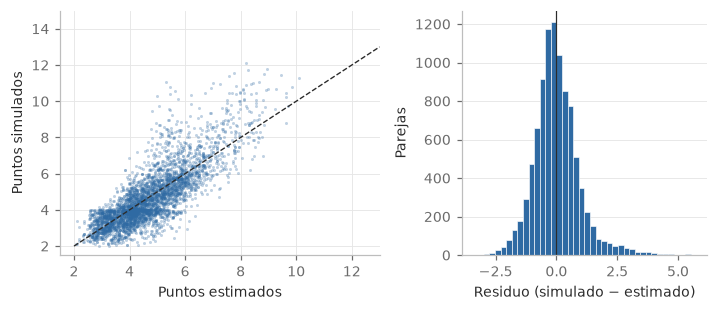

Residuo medio: +0.012 | mediana: -0.076


In [14]:
residuos = prueba[OBJETIVO].values - prediccion
indices = np.random.default_rng(0).choice(len(prueba), 4000, replace=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.9), gridspec_kw={"width_ratios": [1.3, 1]})
a1.scatter(prediccion[indices], prueba[OBJETIVO].values[indices], s=4, alpha=0.3, color=AZUL, linewidths=0)
a1.plot([2, 13], [2, 13], color=TINTA, lw=0.9, ls="--")
a1.set_xlabel("Puntos estimados")
a1.set_ylabel("Puntos simulados")
a1.set_xlim(1.5, 13)
a1.set_ylim(1.5, 15)
a2.hist(residuos, bins=40, color=AZUL, edgecolor="white", linewidth=0.4)
a2.axvline(0, color=TINTA, lw=0.8)
a2.set_xlabel("Residuo (simulado − estimado)")
a2.set_ylabel("Parejas")
a2.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():+.3f} | mediana: {np.median(residuos):+.3f}")

*Documento, Capítulo 5: figura «Puntos estimados contra simulados y distribución de los residuos».*

Los residuos se concentran alrededor de cero y son aproximadamente simétricos. En el extremo
superior, el modelo subestima a las parejas excepcionales (quedan por encima de la diagonal): la
regresión suma efectos por separado y no capta del todo la sinergia de una pareja que lo combina
todo. Para la app esto pesa poco, porque esas parejas siguen quedando en los primeros lugares.

## 5. Modelación no supervisada: descubrir las estrategias

Una estimación de puntos dice qué tan buena es una pareja, pero no cómo jugarla. Con agrupamiento
se dejan salir de los datos las familias de estrategia.

El agrupamiento **no se hace sobre el reparto crudo de recursos**, porque eso solo separa «qué
recurso tienes más», que no es una estrategia: al probarlo, los grupos resultantes sacaban
prácticamente los mismos puntos. Se agrupa sobre lo que la pareja **puede construir**, que es lo
que define cómo se juega. La variable objetivo no interviene.

### 5.1 Número de grupos

k = 2  inercia =   172,877  silueta = 0.287
k = 3  inercia =   133,838  silueta = 0.312
k = 4  inercia =   101,080  silueta = 0.355
k = 5  inercia =    78,553  silueta = 0.388
k = 6  inercia =    67,523  silueta = 0.400


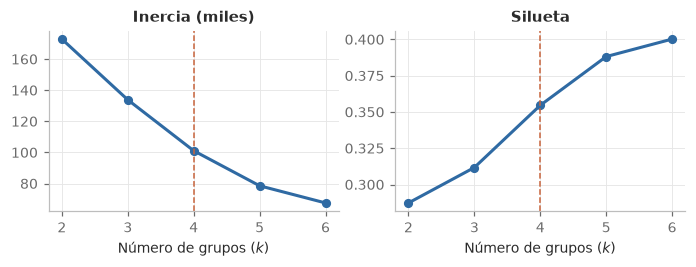

In [15]:
CAPACIDADES = ["par_camino", "par_ciudad", "trio_desarrollo",
               "cuarteto_poblado", "puerto_alineado", "desequilibrio"]

escalador = StandardScaler().fit(datos[CAPACIDADES])
Z = escalador.transform(datos[CAPACIDADES])

# La silueta se calcula sobre una muestra fija de 8,000 parejas (sobre todas sería muy lento).
muestra_silueta = np.random.default_rng(0).choice(len(datos), 8000, replace=False)
ks, inercias, siluetas = list(range(2, 7)), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Z[muestra_silueta], km.labels_[muestra_silueta]))
    print(f"k = {k}  inercia = {km.inertia_:9,.0f}  silueta = {siluetas[-1]:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.4, 2.5))
a1.plot(ks, np.array(inercias) / 1000, color=AZUL, lw=2, marker="o", ms=5)
a1.set_xlabel("Número de grupos ($k$)")
a1.set_title("Inercia (miles)")
a2.plot(ks, siluetas, color=AZUL, lw=2, marker="o", ms=5)
a2.set_xlabel("Número de grupos ($k$)")
a2.set_title("Silueta")
for a in (a1, a2):
    a.axvline(4, color=TERRACOTA, lw=1, ls="--")
    a.set_xticks(ks)
plt.tight_layout()
plt.show()

*Documento, Capítulo 5: figura «Inercia y coeficiente de silueta según el número de grupos».*

La inercia baja de forma gradual, sin un codo marcado, y la silueta sigue subiendo con más grupos,
lo que es habitual y no decide por sí solo. Se eligen **cuatro** porque es donde los grupos se
corresponden con estrategias reconocibles del juego y con resultados claramente distintos, que es
el criterio útil para el producto.

### 5.2 Las cuatro familias, con el nombre que les corresponde

*K-means* numera los grupos de forma arbitraria, así que no se pueden nombrar a mano: se deduce
qué es cada uno mirando su centro, por eliminación. Es la misma regla que usa la app
(`_nombrar_grupos()` en `backend/app/services/recomendador.py`).

In [16]:
agrupamiento = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Z)
centros = pd.DataFrame(agrupamiento.cluster_centers_, columns=CAPACIDADES)

nombres, libres = {}, set(range(4))
for capacidad, familia in [("puerto_alineado", "Puerto"),
                           ("par_camino", "Expansión"),
                           ("trio_desarrollo", "Ciudades y desarrollo")]:
    g = max(libres, key=lambda i: centros.loc[i, capacidad])
    nombres[g] = familia
    libres.remove(g)
nombres[libres.pop()] = "Desequilibrada"

datos["familia"] = pd.Series(agrupamiento.labels_, index=datos.index).map(nombres)
ORDEN = ["Expansión", "Ciudades y desarrollo", "Puerto", "Desequilibrada"]
COLOR_FAMILIA = {"Expansión": AZUL, "Ciudades y desarrollo": TERRACOTA, "Puerto": VERDE, "Desequilibrada": DORADO}

perfil = datos.groupby("familia").agg(
    parejas=(OBJETIVO, "size"),
    puntos=(OBJETIVO, "mean"),
    produccion_efectiva=("produccion_efectiva", "mean"),
    pips=("pips_totales", "mean"),
    camino=("par_camino", "mean"),
    ciudad=("par_ciudad", "mean"),
    desarrollo=("trio_desarrollo", "mean"),
    poblado=("cuarteto_poblado", "mean"),
    puerto=("puerto_alineado", "mean"),
    desequilibrio=("desequilibrio", "mean"),
).loc[ORDEN]
perfil.insert(1, "%", perfil["parejas"] / len(datos) * 100)
perfil.round(2)

,parejas,%,puntos,produccion_efectiva,pips,camino,ciudad,desarrollo,poblado,puerto,desequilibrio
familia,,,,,,,,,,,
Expansión,10753,28.04,5.54,15.36,19.32,3.97,0.35,0.36,1.28,0.0,0.39
Ciudades y desarrollo,9978,26.01,5.17,14.86,19.08,0.33,1.56,2.62,0.22,0.0,0.41
Puerto,2876,7.50,4.47,12.20,15.85,1.20,0.45,0.52,0.18,1.0,0.50
Desequilibrada,14748,38.45,3.71,11.69,17.50,0.54,0.20,0.08,0.02,0.0,0.56


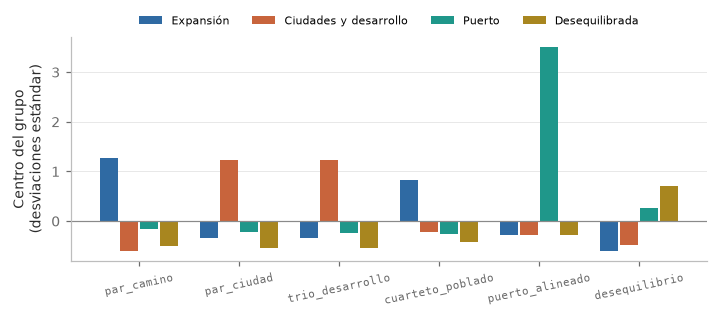

In [17]:
centros.index = [nombres[i] for i in centros.index]
centros = centros.loc[ORDEN]

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ancho, x = 0.2, np.arange(len(CAPACIDADES))
for n, (familia, fila) in enumerate(centros.iterrows()):
    ax.bar(x + (n - 1.5) * ancho, fila.values, width=ancho * 0.92, color=COLOR_FAMILIA[familia], label=familia)
ax.axhline(0, color="#8a8a8a", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CAPACIDADES, fontsize=7.5, family="DejaVu Sans Mono", rotation=12)
ax.set_ylabel("Centro del grupo\n(desviaciones estándar)")
ax.legend(fontsize=7.5, frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.14))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 5: figura «Centro de cada familia en las seis variables del agrupamiento».*

El algoritmo agrupa; ponerles nombre es trabajo de quien conoce el juego. Mirando los perfiles:

**Expansión.** Mucho `par_camino` y `cuarteto_poblado`. Construye caminos y poblados desde temprano
y pelea la carta de camino más largo. Es la familia con más puntos.

**Ciudades y desarrollo.** Alto en `par_ciudad` y `trio_desarrollo`. Crece hacia arriba subiendo
poblados a ciudades y comprando cartas. Segunda en puntos.

**Puerto.** Se distingue por `puerto_alineado`. Es la de **menos producción** y aun así no es la
peor: concentra un recurso y lo convierte a mitad de precio. Es una jugada de nicho que funciona,
y confirma con datos una intuición de jugadora.

**Desequilibrada.** Casi ninguna combinación completa y el `desequilibrio` más alto. Produce sin
poder gastar. Es la peor.

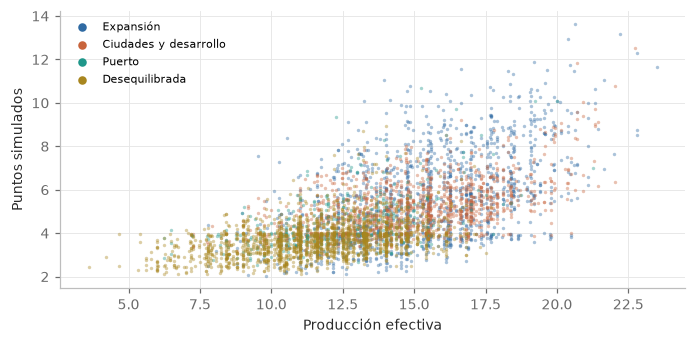

In [18]:
muestra = datos.sample(5000, random_state=0)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for familia in ORDEN:
    t = muestra[muestra["familia"] == familia]
    ax.scatter(t["produccion_efectiva"], t[OBJETIVO], s=5, alpha=0.4,
               color=COLOR_FAMILIA[familia], label=familia, linewidths=0)
leyenda = ax.legend(fontsize=7.5, frameon=False, markerscale=2.5, loc="upper left")
for h in leyenda.legend_handles:
    h.set_alpha(1)
ax.set_xlabel("Producción efectiva")
ax.set_ylabel("Puntos simulados")
plt.tight_layout()
plt.show()

*Documento, Capítulo 5: figura «Producción efectiva contra puntos simulados, por familia de estrategia».*

In [19]:
# ¿En qué familia cae la pareja que elegiría un jugador por pips?
pareja_por_pips = datos.loc[datos.groupby("tablero_id")["pips_totales"].idxmax()]
(pareja_por_pips["familia"].value_counts(normalize=True) * 100).round(0).to_frame("% de los tableros")

,% de los tableros
familia,
Expansión,43.0
Ciudades y desarrollo,34.0
Desequilibrada,23.0


En casi una cuarta parte de los tableros, la pareja con más pips cae en la familia
**desequilibrada**: mucha producción que no se puede gastar.

En la app, las familias deciden qué opciones se muestran: la opción 1 es la de mayor estimación,
sea de la familia que sea; las opciones 2 y 3 son las mejores de **otras** familias, para elegir
entre estrategias distintas. La desequilibrada nunca se ofrece como alternativa.

## 6. Guardar el modelo para la aplicación

El modelo final se reentrena con los 200 tableros. La app carga este archivo y solo hace
inferencia. La estructura del diccionario es la que espera `backend/app/services/recomendador.py`.

In [20]:
final = make_pipeline(StandardScaler(), LinearRegression()).fit(datos[VARIABLES], datos[OBJETIVO])
agrupamiento_final = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Z)

(RAIZ / "modelos").mkdir(exist_ok=True)
joblib.dump({
    "modelo": final,
    "variables": VARIABLES,
    "agrupamiento": agrupamiento_final,
    "escalador_capacidades": escalador,
    "capacidades": CAPACIDADES,
    "r2_prueba": round(r2, 3),
    "mae_prueba": round(mae, 3),
}, RAIZ / "backend" / "modelos" / "colono.joblib")

print("Guardado en modelos/colono.joblib")

Guardado en modelos/colono.joblib


## 7. Conclusiones

Son las mismas del Capítulo 5 del documento.

**Una regresión lineal con 12 variables basta para elegir bien.** R² de 0.64 en tableros nuevos y
un error medio de 0.70 puntos, frente a una variación natural de 1.6. Añadir 28 variables más sube
el R² unas centésimas y estropea la interpretación.

**El modelo elige mucho mejor que los pips.** Su pareja recomendada saca alrededor de dos puntos de
victoria más que la que elige cualquier jugador por pips, y captura cerca del 77 % del margen
disponible, frente al 29 % de los pips.

**Un modelo más complejo apenas elige mejor.** El *gradient boosting* predice con más precisión,
pero en la decisión que importa solo gana unas tres décimas, a cambio de perder la explicación.

**Lo que no se explica no son los dados.** El ruido de la simulación es una parte muy pequeña de la
varianza; el resto son relaciones no lineales, una mejora posible para versiones futuras.

**Lo que más pesa es poder construir, no producir.** Los coeficientes más grandes son combinaciones
completas de recursos.

**El puerto alineado suma, aunque la correlación dijera lo contrario.** Al controlar por la
producción, el coeficiente se vuelve positivo.

**Cuatro familias de estrategia salen solas de los datos** y se corresponden con jugadas
reconocibles: expansión, ciudades y desarrollo, puerto, y desequilibrada. La app usa esta
clasificación para explicar cada recomendación.

**Limitaciones.** El simulador sigue a un solo jugador, sin rivales que bloqueen ni intercambios
entre jugadores, y la política de construcción es fija. Los resultados valen para comparar parejas
entre sí, que es lo que la app necesita, no como pronóstico absoluto de una partida real.